# Part 2.1 — OCT Retinal Images with a DCGAN (OCTMNIST)

Training a **DCGAN** (a convolutional GAN) to generate fake retinal OCT scans, then comparing them to the real ones with **FID**. The extension at the end is a **conditional GAN (cGAN)** that can generate a chosen class on demand.



## 1. Setup

In [1]:
!pip install medmnist torchmetrics -q

import os, torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torchvision.utils as vutils
import medmnist
from medmnist import INFO, OCTMNIST

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)          # should say cuda
classes = INFO['octmnist']['label']
print(classes)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.1 MB/s eta 0:00:00
Device: cuda
{'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}


In [2]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=["#3b82f6", "#f97316", "#10b981", "#ef4444", "#8b5cf6"])

## 2. Download the dataset

MedMNIST's automatic download times out sometimes (HTTP 504), so I download the `octmnist.npz` file directly from the Zenodo mirror into the folder MedMNIST reads from (`~/.medmnist`). After this, loading is offline and reliable.

In [3]:
os.makedirs("/root/.medmnist", exist_ok=True)
npz_path = "/root/.medmnist/octmnist.npz"

if not os.path.exists(npz_path):
    !wget -q --tries=3 -O /root/.medmnist/octmnist.npz "https://zenodo.org/records/10519652/files/octmnist.npz?download=1"

print("File in place:", os.path.exists(npz_path),
      "| size (MB):", round(os.path.getsize(npz_path)/1e6, 1) if os.path.exists(npz_path) else 0)

File in place: True | size (MB): 54.9


## 3. Load and explore the data

OCTMNIST is 28×28 grayscale retinal scans in 4 classes. The file is already downloaded, so `download=True` just loads it locally. Checking the class balance and looking at some real samples.

Train images: (97477, 28, 28) | pixels: 0 - 255
0 (choroidal neovascularization): 33484
1 (diabetic macular edema): 10213
2 (drusen): 7754
3 (normal): 46026


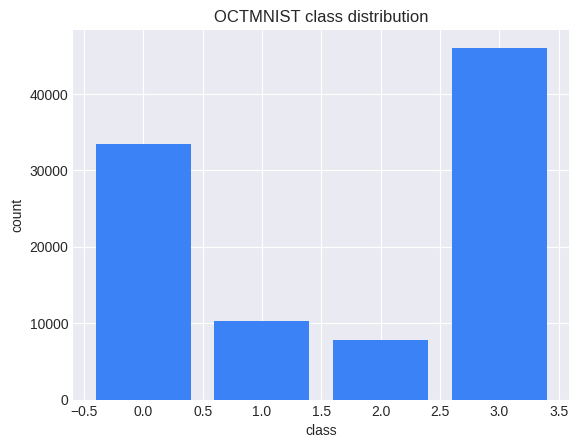

In [4]:
train_ds_raw = OCTMNIST(split="train", download=True, size=28)   # loads from local npz
imgs   = train_ds_raw.imgs
labels = train_ds_raw.labels.flatten()
print("Train images:", imgs.shape, "| pixels:", imgs.min(), "-", imgs.max())

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"{i} ({classes[str(i)]}): {c}")

plt.bar(range(len(counts)), counts)
plt.title("OCTMNIST class distribution"); plt.xlabel("class"); plt.ylabel("count")
plt.show()

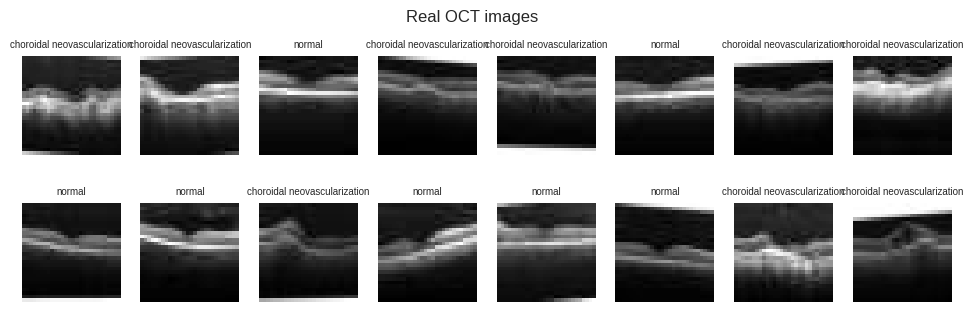

In [5]:
fig, ax = plt.subplots(2, 8, figsize=(12, 3.5))
for a in ax.flat:
    j = np.random.randint(len(imgs))
    a.imshow(imgs[j], cmap="gray"); a.axis("off")
    a.set_title(classes[str(labels[j])], fontsize=7)
plt.suptitle("Real OCT images"); plt.show()

## 4. Prepare the data for training

Resize to 32×32 (clean powers of two for the conv layers) and normalise pixels to `[-1, 1]` to match the generator's `Tanh` output.

In [6]:
transform = T.Compose([
    T.Resize(32),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),      # -> [-1, 1]
])

train_ds = OCTMNIST(split="train", download=True, size=28, transform=transform)
batch_size = 128
loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size,
                                     shuffle=True, num_workers=2, drop_last=True)
print("Batches per epoch:", len(loader))

Batches per epoch: 761


## 5. DCGAN models

**Generator:** noise vector → transposed convolutions upsampling 1×1 → 32×32, BatchNorm + ReLU, `Tanh` output.
**Discriminator:** convolutions downsampling the image to one real/fake probability, LeakyReLU + BatchNorm, `Sigmoid` output.

In [7]:
nz, ngf, ndf = 100, 64, 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 1, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).view(-1, 1)

DCGAN trains best with weights initialised from a small normal distribution.

In [8]:
def weights_init(m):
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator().to(device); G.apply(weights_init)
D = Discriminator().to(device); D.apply(weights_init)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

## 6. Train

BCE loss, Adam (lr 0.0002, beta1 0.5). Tracking both losses; a fixed noise batch lets me watch the same fakes improve.

In [9]:
criterion = nn.BCELoss()   # binary cross-entropy, shared with the cGAN section below

def train_dcgan(loader, num_epochs=30):
    """Train an unconditional DCGAN on `loader`.
    Returns the trained G and D, the per-epoch loss histories, and a fixed noise batch."""
    G = Generator().to(device); G.apply(weights_init)       # fresh generator + DCGAN weight init
    D = Discriminator().to(device); D.apply(weights_init)   # fresh discriminator + DCGAN weight init
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))  # discriminator optimiser
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))  # generator optimiser
    fixed_noise = torch.randn(64, nz, 1, 1, device=device)  # constant noise so progress is comparable
    G_losses, D_losses = [], []

    for epoch in range(num_epochs):
        for real, _ in loader:                              # labels ignored (unconditional GAN)
            real = real.to(device)
            bs = real.size(0)
            # ---- train discriminator: D(real) -> 1, D(fake) -> 0 ----
            D.zero_grad()
            loss_real = criterion(D(real), torch.ones(bs, 1, device=device))    # real should score 1
            z = torch.randn(bs, nz, 1, 1, device=device)                        # sample latent noise
            fake = G(z)                                                         # generate a fake batch
            loss_fake = criterion(D(fake.detach()), torch.zeros(bs, 1, device=device))  # fakes score 0 (detach so G isn't updated here)
            loss_D = loss_real + loss_fake
            loss_D.backward(); opt_D.step()
            # ---- train generator: wants D to call its fakes real ----
            G.zero_grad()
            loss_G = criterion(D(fake), torch.ones(bs, 1, device=device))       # reward fooling D
            loss_G.backward(); opt_G.step()
        G_losses.append(loss_G.item()); D_losses.append(loss_D.item())          # record epoch losses
        print(f"Epoch {epoch+1:2d}/{num_epochs} | D {loss_D.item():.3f} | G {loss_G.item():.3f}")
    return G, D, G_losses, D_losses, fixed_noise

# train, and keep the returned objects for the cells below
G, D, G_losses, D_losses, fixed_noise = train_dcgan(loader)

Epoch  1/30 | D 0.406 | G 1.732
Epoch  2/30 | D 0.338 | G 2.138
Epoch  3/30 | D 0.050 | G 3.472
Epoch  4/30 | D 0.065 | G 4.516
Epoch  5/30 | D 0.953 | G 0.837
Epoch  6/30 | D 0.388 | G 4.549
Epoch  7/30 | D 0.025 | G 4.655
Epoch  8/30 | D 0.143 | G 3.762
Epoch  9/30 | D 0.027 | G 4.661
Epoch 10/30 | D 0.479 | G 1.954
Epoch 11/30 | D 1.197 | G 0.670
Epoch 12/30 | D 0.103 | G 3.759
Epoch 13/30 | D 0.008 | G 7.292
Epoch 14/30 | D 0.017 | G 5.965
Epoch 15/30 | D 0.066 | G 5.330
Epoch 16/30 | D 0.663 | G 4.140
Epoch 17/30 | D 0.196 | G 3.616
Epoch 18/30 | D 0.422 | G 2.932
Epoch 19/30 | D 0.022 | G 4.861
Epoch 20/30 | D 0.133 | G 4.322
Epoch 21/30 | D 0.018 | G 6.135
Epoch 22/30 | D 0.610 | G 3.806
Epoch 23/30 | D 0.294 | G 2.690
Epoch 24/30 | D 0.304 | G 3.631
Epoch 25/30 | D 0.012 | G 5.838
Epoch 26/30 | D 0.010 | G 5.936
Epoch 27/30 | D 0.030 | G 4.693
Epoch 28/30 | D 0.020 | G 5.497
Epoch 29/30 | D 0.092 | G 4.798
Epoch 30/30 | D 0.046 | G 4.968


### Loss curves

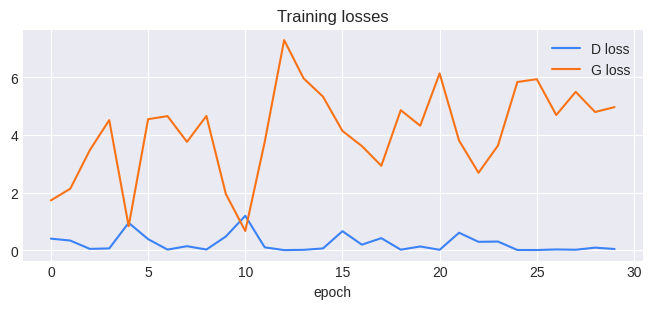

In [10]:
plt.figure(figsize=(8,3))
plt.plot(D_losses, label="D loss"); plt.plot(G_losses, label="G loss")
plt.xlabel("epoch"); plt.legend(); plt.title("Training losses"); plt.show()

## 7. Generate fake images

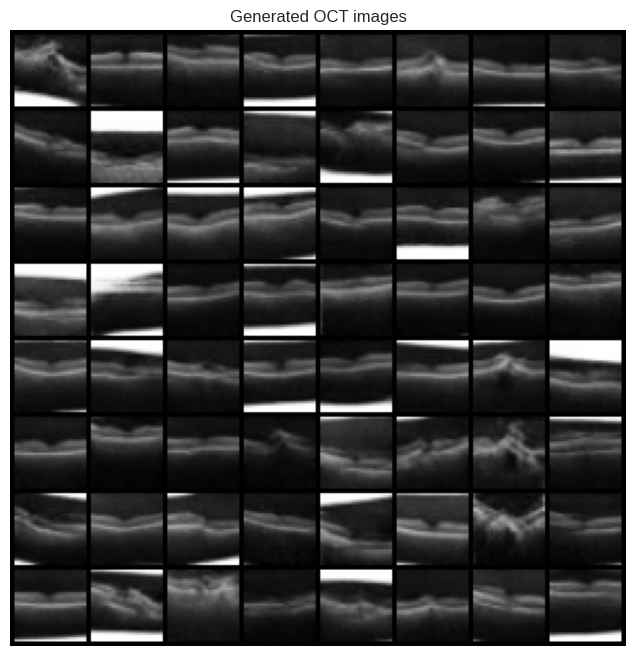

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

In [11]:
G.eval()
with torch.no_grad():
    fake = G(fixed_noise).cpu()
grid = vutils.make_grid(fake, nrow=8, normalize=True)
plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray"); plt.axis("off")
plt.title("Generated OCT images"); plt.show()
G.train()

## 8. Evaluate with FID

**FID** measures how close the fake distribution is to the real one — lower is better. Inception needs 3-channel images, so grayscale is repeated to 3 channels. `feature=64` since the dataset is small.

In [12]:
!pip install torch-fidelity -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.4 MB/s eta 0:00:00


In [13]:
import torchmetrics.image.fid as _fidmod
_fidmod._TORCH_FIDELITY_AVAILABLE = True

In [14]:
import numpy as np
import torch.nn.functional as F
from torchvision.models import inception_v3
from scipy import linalg

# InceptionV3 as a 2048-d feature extractor (downloads weights once)
incep = inception_v3(weights="DEFAULT", transform_input=False).to(device)
incep.fc = torch.nn.Identity()
incep.eval()

_mean = torch.tensor([0.485,0.456,0.406], device=device).view(1,3,1,1)
_std  = torch.tensor([0.229,0.224,0.225], device=device).view(1,3,1,1)

def get_features(imgs):                       # imgs in [-1,1], (N,1,32,32)
    feats = []
    with torch.no_grad():
        for i in range(0, imgs.size(0), 100):
            x = (imgs[i:i+100] + 1) / 2         # -> [0,1]
            x = x.repeat(1, 3, 1, 1)            # -> 3 channels
            x = F.interpolate(x, size=(299,299), mode="bilinear", align_corners=False)
            x = (x - _mean) / _std
            feats.append(incep(x).cpu().numpy())
    return np.concatenate(feats, 0)

def fid_score(real_imgs, fake_imgs):
    fr, ff = get_features(real_imgs), get_features(fake_imgs)
    mu1, s1 = fr.mean(0), np.cov(fr, rowvar=False)
    mu2, s2 = ff.mean(0), np.cov(ff, rowvar=False)
    diff = mu1 - mu2
    covmean = linalg.sqrtm(s1.dot(s2))
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff.dot(diff) + np.trace(s1 + s2 - 2*covmean))

# gather real + fake samples and score
n_eval = 2000
real_eval = torch.stack([train_ds[i][0] for i in range(n_eval)]).to(device)
G.eval()
with torch.no_grad():
    fake_eval = torch.cat([G(torch.randn(200, nz, 1, 1, device=device)) for _ in range(n_eval//200)])
G.train()

print("FID:", fid_score(real_eval, fake_eval))

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 148MB/s] 


FID: 32.715350973391715


### Real vs fake side by side

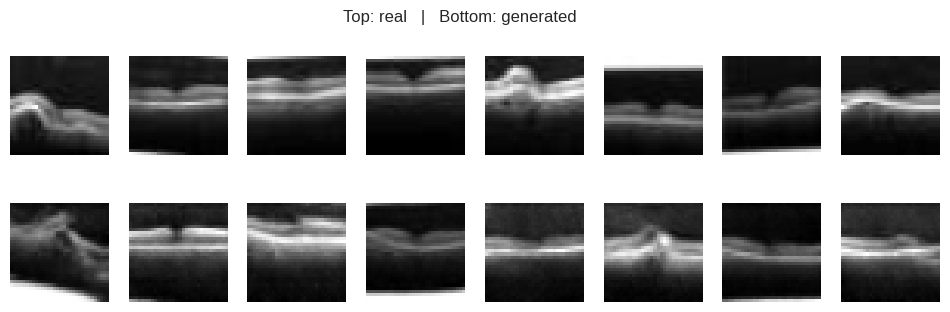

In [15]:
fig, ax = plt.subplots(2, 8, figsize=(12, 3.5))
for k in range(8):
    ax[0,k].imshow(train_ds[k][0].squeeze()*0.5+0.5, cmap="gray"); ax[0,k].axis("off")
    ax[1,k].imshow(fake[k].squeeze()*0.5+0.5, cmap="gray"); ax[1,k].axis("off")
plt.suptitle("Top: real   |   Bottom: generated"); plt.show()

## 9. Reflection
The generated images resemble real OCT scans quite well. Most of the synthetic images capture the overall layered structure of the retina, particularly the bright horizontal bands that are visible in the real samples. When comparing the real and generated images side by side, the generator has learned the general appearance of retinal scans, although some of the finer details and sharp boundaries between layers are less distinct. The generated images appear slightly smoother than the real ones, but they still look realistic overall.

The model achieved an FID score of 32.72. Since a lower FID indicates that the generated images are closer to the real data distribution, this result suggests that the DCGAN was able to generate reasonably realistic OCT images. While the score is not close to zero, it is a good outcome for a standard DCGAN trained for a limited number of epochs and indicates that the model successfully learned the main characteristics of the dataset.

There are still some visible limitations. A few generated images are slightly blurred and lack the fine texture present in the original OCT scans. Some images also look quite similar to one another, suggesting that the generator has not captured the full variation within the dataset. However, there is no obvious evidence of severe mode collapse, as the generated images still show noticeable differences in retinal shape and brightness.

GANs are not limited to medical imaging and can be used to generate many other types of images, such as handwritten digits, faces, animals and simple objects like ducks. This demonstrates that the same adversarial learning approach can model a wide range of image distributions depending on the training data. In medical applications, GANs are particularly useful because they can generate additional synthetic images to support model training while helping to preserve patient privacy.

The quality of the generated images could be improved by training for more epochs, increasing the amount of training data or using more advanced GAN architectures such as WGAN-GP or StyleGAN, which generally produce sharper images and provide more stable training. Fine-tuning the learning rate and other hyperparameters could also help the generator learn more detailed retinal structures.

## 10. Extension — Conditional GAN (cGAN)

Now the generator is told **which class** to produce. The generator concatenates a label embedding to the noise; the discriminator gets the label as an extra image channel. After training I can request any class on demand.

In [16]:
num_classes = len(classes)

class CGenerator(nn.Module):
    def __init__(self, embed=50):
        super().__init__()
        self.emb = nn.Embedding(num_classes, embed)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz+embed, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 1, 4, 2, 1, bias=False), nn.Tanh(),
        )
    def forward(self, z, y):
        e = self.emb(y).unsqueeze(-1).unsqueeze(-1)
        return self.net(torch.cat([z, e], 1))

class CDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(num_classes, 32*32)
        self.net = nn.Sequential(
            nn.Conv2d(2, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False), nn.Sigmoid(),
        )
    def forward(self, x, y):
        e = self.emb(y).view(-1, 1, 32, 32)
        return self.net(torch.cat([x, e], 1)).view(-1, 1)

cG = CGenerator().to(device); cG.apply(weights_init)
cD = CDiscriminator().to(device); cD.apply(weights_init)

CDiscriminator(
  (emb): Embedding(4, 1024)
  (net): Sequential(
    (0): Conv2d(2, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

In [18]:
opt_cD = torch.optim.Adam(cD.parameters(), lr=1e-4, betas=(0.5, 0.999))
opt_cG = torch.optim.Adam(cG.parameters(), lr=2e-4, betas=(0.5, 0.999))
num_epochs = 30
real_target = 0.9

for epoch in range(num_epochs):
    for real, y in loader:
        real = real.to(device); y = y.squeeze().long().to(device)
        bs = real.size(0)
        cD.zero_grad()
        loss_real = criterion(cD(real, y), torch.full((bs,1), real_target, device=device))
        z = torch.randn(bs, nz, 1, 1, device=device)
        y_fake = torch.randint(0, num_classes, (bs,), device=device)
        fake = cG(z, y_fake)
        loss_fake = criterion(cD(fake.detach(), y_fake), torch.zeros(bs,1,device=device))
        loss_D = loss_real + loss_fake
        loss_D.backward(); opt_cD.step()
        for _ in range(2):
            z = torch.randn(bs, nz, 1, 1, device=device)
            y_fake = torch.randint(0, num_classes, (bs,), device=device)
            cG.zero_grad()
            loss_G = criterion(cD(cG(z, y_fake), y_fake), torch.ones(bs,1,device=device))
            loss_G.backward(); opt_cG.step()
    print(f"Epoch {epoch+1:2d}/{num_epochs} | D {loss_D.item():.3f} | G {loss_G.item():.3f}")

Epoch  1/30 | D 0.357 | G 5.206
Epoch  2/30 | D 0.341 | G 7.830
Epoch  3/30 | D 0.337 | G 7.058
Epoch  4/30 | D 0.326 | G 7.859
Epoch  5/30 | D 0.337 | G 6.985
Epoch  6/30 | D 0.327 | G 9.085
Epoch  7/30 | D 0.418 | G 2.398
Epoch  8/30 | D 0.325 | G 8.180
Epoch  9/30 | D 0.327 | G 7.810
Epoch 10/30 | D 0.328 | G 11.313
Epoch 11/30 | D 0.327 | G 10.142
Epoch 12/30 | D 0.326 | G 12.213
Epoch 13/30 | D 0.331 | G 9.155
Epoch 14/30 | D 0.346 | G 6.318
Epoch 15/30 | D 0.325 | G 10.079
Epoch 16/30 | D 0.337 | G 8.642
Epoch 17/30 | D 0.325 | G 10.963
Epoch 18/30 | D 0.325 | G 8.971
Epoch 19/30 | D 0.326 | G 12.050
Epoch 20/30 | D 0.325 | G 10.156
Epoch 21/30 | D 0.328 | G 8.437
Epoch 22/30 | D 0.326 | G 9.305
Epoch 23/30 | D 0.325 | G 9.695
Epoch 24/30 | D 0.326 | G 11.079
Epoch 25/30 | D 0.327 | G 12.762
Epoch 26/30 | D 0.326 | G 9.243
Epoch 27/30 | D 0.325 | G 12.973
Epoch 28/30 | D 0.329 | G 4.054
Epoch 29/30 | D 0.327 | G 8.601
Epoch 30/30 | D 0.326 | G 12.694


### Generate specific classes on demand

Each row is one class — the generator is asked for that class explicitly.

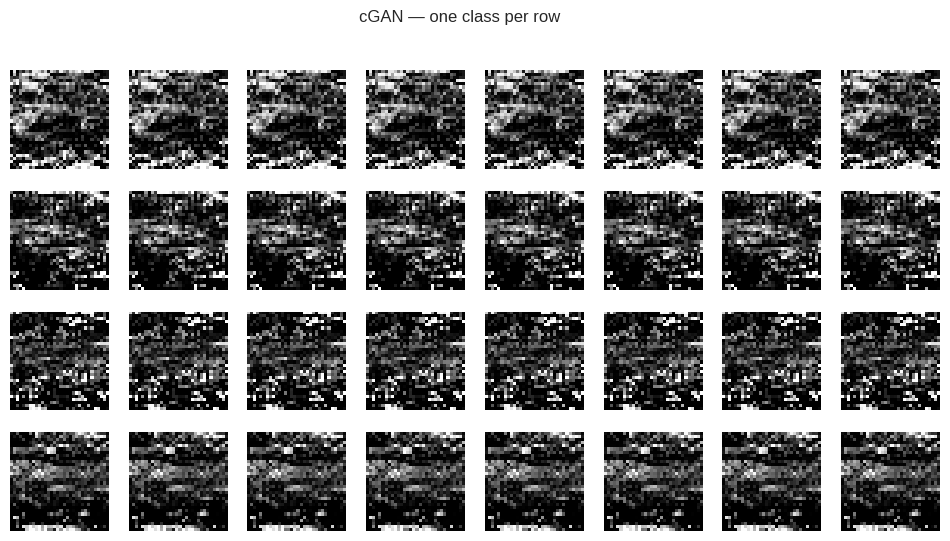

CGenerator(
  (emb): Embedding(4, 50)
  (net): Sequential(
    (0): ConvTranspose2d(150, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

In [19]:
cG.eval()
fig, ax = plt.subplots(num_classes, 8, figsize=(12, 1.5*num_classes))
with torch.no_grad():
    for cls in range(num_classes):
        z = torch.randn(8, nz, 1, 1, device=device)
        y = torch.full((8,), cls, device=device)
        out = cG(z, y).cpu()
        for k in range(8):
            ax[cls,k].imshow(out[k].squeeze()*0.5+0.5, cmap="gray"); ax[cls,k].axis("off")
        ax[cls,0].set_ylabel(classes[str(cls)], fontsize=7, rotation=0, labelpad=40)
plt.suptitle("cGAN — one class per row"); plt.show()
cG.train()